# Erweiterte Analyse aller Parameter-Sweep-Settings

Dieses Notebook erweitert die feste Setting-Analyse um eine systematische Auswertung **aller** Subfolder im Sweep.

Analysiert werden pro Setting:
- `muscle_length_prestretch.csv`: Vergleich der zwei Eintraege (`L_orig`, `L_prestretch`)
- `muscle_length_contraction.csv`: Zeitreihe ohne Header, 1 Wert pro ms

Ziel: wissenschaftlich belastbare Kennzahlen und Zusammenhaenge zwischen Parametern und Zeitverlaeufen.

## 1. Arbeitsumgebung und Imports

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Optional: statsmodels fuer robuste/lineare Modelle
try:
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False

# Reproduzierbare Plot-Konfiguration
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

print("Imports geladen. Statsmodels verfuegbar:", HAS_STATSMODELS)

Imports geladen. Statsmodels verfuegbar: True


## 2. Basispfad setzen und Setting-Ordner rekursiv erfassen

In [2]:
root_dir = Path("/Users/canis/Library/CloudStorage/OneDrive-Persönlich/work/SdV/natwissKolleg/results/final_results/results_for_paper/da_4/new/parameter_sweep_DA_20260227_194745/archived_results")

assert root_dir.exists(), f"Root-Verzeichnis nicht gefunden: {root_dir}"

# Kandidaten: alle unmittelbaren Subfolder von archived_results
setting_dirs = sorted([p for p in root_dir.iterdir() if p.is_dir()])

records_availability = []
for d in setting_dirs:
    prestretch_file = d / "muscle_length_prestretch.csv"
    contraction_file = d / "muscle_length_contraction.csv"
    records_availability.append(
        {
            "setting_dir": d,
            "setting_name": d.name,
            "prestretch_exists": prestretch_file.exists(),
            "contraction_exists": contraction_file.exists(),
        }
    )

availability_df = pd.DataFrame(records_availability)
print(f"Anzahl gefundener Setting-Ordner: {len(availability_df)}")
print(availability_df[["prestretch_exists", "contraction_exists"]].value_counts(dropna=False).rename("count"))

valid_settings_df = availability_df[
    availability_df["prestretch_exists"] & availability_df["contraction_exists"]
].copy()

print(f"Valide Settings (beide Dateien vorhanden): {len(valid_settings_df)}")
valid_settings_df.head(3)

Anzahl gefundener Setting-Ordner: 700
prestretch_exists  contraction_exists
True               True                  700
Name: count, dtype: int64
Valide Settings (beide Dateien vorhanden): 700


,setting_dir,setting_name,prestretch_exists,contraction_exists
0,/Users/canis/Library/CloudStorage/OneDrive-Per...,F00_ratio10.1000_Vol421.6_Am450_rho10.493,True,True
1,/Users/canis/Library/CloudStorage/OneDrive-Per...,F00_ratio10.1000_Vol421.6_Am450_rho10.534,True,True
2,/Users/canis/Library/CloudStorage/OneDrive-Per...,F00_ratio10.1000_Vol421.6_Am450_rho10.575,True,True


## 3. Parameter aus Ordnernamen parsen (F, ratio, Vol, Am, rho)

In [3]:
pattern = re.compile(
    r"^F(?P<F>\d+)_ratio(?P<ratio>[0-9.]+)_Vol(?P<Vol>[0-9.]+)_Am(?P<Am>[0-9.]+)_rho(?P<rho>[0-9.]+)$"
)

def parse_setting_name(name: str):
    m = pattern.match(name)
    if m is None:
        return None
    d = m.groupdict()
    return {
        "F": int(d["F"]),
        "ratio": float(d["ratio"]),
        "Vol": float(d["Vol"]),
        "Am": float(d["Am"]),
        "rho": float(d["rho"]),
    }

parsed_rows = []
for _, row in valid_settings_df.iterrows():
    parsed = parse_setting_name(row["setting_name"])
    parsed_rows.append(
        {
            **row.to_dict(),
            "parsed_ok": parsed is not None,
            **(parsed if parsed is not None else {}),
        }
    )

meta_df = pd.DataFrame(parsed_rows)
meta_df = meta_df[meta_df["parsed_ok"]].copy()
meta_df["setting_id"] = np.arange(len(meta_df))

print(f"Erfolgreich geparste Settings: {len(meta_df)}")
print("Parameter-Auspraegungen:")
for col in ["F", "ratio", "Vol", "Am", "rho"]:
    vals = sorted(meta_df[col].unique())
    print(f"  {col}: {len(vals)} Werte, Beispiel: {vals[:5]}{' ...' if len(vals) > 5 else ''}")

meta_df.head(3)

Erfolgreich geparste Settings: 700
Parameter-Auspraegungen:
  F: 16 Werte, Beispiel: [0, 3, 6, 9, 12] ...
  ratio: 4 Werte, Beispiel: [6.88, 7.9533, 9.0267, 10.1]
  Vol: 1 Werte, Beispiel: [421.6]
  Am: 3 Werte, Beispiel: [450.0, 500.0, 550.0]
  rho: 4 Werte, Beispiel: [10.493, 10.534, 10.575, 10.616]


,setting_dir,setting_name,prestretch_exists,contraction_exists,parsed_ok,F,ratio,Vol,Am,rho,setting_id
0,/Users/canis/Library/CloudStorage/OneDrive-Per...,F00_ratio10.1000_Vol421.6_Am450_rho10.493,True,True,True,0,10.1,421.6,450.0,10.493,0
1,/Users/canis/Library/CloudStorage/OneDrive-Per...,F00_ratio10.1000_Vol421.6_Am450_rho10.534,True,True,True,0,10.1,421.6,450.0,10.534,1
2,/Users/canis/Library/CloudStorage/OneDrive-Per...,F00_ratio10.1000_Vol421.6_Am450_rho10.575,True,True,True,0,10.1,421.6,450.0,10.575,2


## 4. `muscle_length_prestretch.csv` laden und 2-Werte-Vergleich berechnen

In [4]:
def read_csv_as_float_list(path: Path):
    text = path.read_text().strip()
    if not text:
        return []
    parts = [p.strip() for p in text.split(",") if p.strip() != ""]
    return [float(p) for p in parts]

prestretch_rows = []
prestretch_issues = []

for _, row in meta_df.iterrows():
    setting_dir = row["setting_dir"]
    fpath = setting_dir / "muscle_length_prestretch.csv"
    vals = read_csv_as_float_list(fpath)

    if len(vals) < 2:
        prestretch_issues.append((row["setting_name"], len(vals)))
        l_orig = np.nan
        l_pre = np.nan
    else:
        l_orig = vals[0]
        l_pre = vals[1]

    dL = l_pre - l_orig if np.isfinite(l_orig) and np.isfinite(l_pre) else np.nan
    dL_rel = (dL / l_orig) if np.isfinite(dL) and l_orig != 0 else np.nan

    prestretch_rows.append(
        {
            "setting_id": row["setting_id"],
            "L_orig": l_orig,
            "L_prestretch": l_pre,
            "dL_prestretch": dL,
            "dL_rel_prestretch": dL_rel,
            "n_prestretch_values": len(vals),
        }
    )

prestretch_df = pd.DataFrame(prestretch_rows)

print(f"Prestretch-Zeilen erstellt: {len(prestretch_df)}")
print(f"Settings mit <2 Werten in prestretch-Datei: {len(prestretch_issues)}")
if prestretch_issues:
    print("Beispiele Probleme:", prestretch_issues[:5])

print("\nPrestretch-Differenz-Statistik:")
print(prestretch_df[["dL_prestretch", "dL_rel_prestretch"]].describe().T)
prestretch_df.head(3)

Prestretch-Zeilen erstellt: 700
Settings mit <2 Werten in prestretch-Datei: 0

Prestretch-Differenz-Statistik:
                   count      mean       std  min       25%       50%        75%        max
dL_prestretch      700.0  9.252529  7.089298  0.0  2.760503  7.743475  15.404957  24.760844
dL_rel_prestretch  700.0  0.301081  0.228455  0.0  0.078791  0.233511   0.473887   0.706726


,setting_id,L_orig,L_prestretch,dL_prestretch,dL_rel_prestretch,n_prestretch_values
0,0,35.03597,35.03597,0.0,0.0,2
1,1,35.03597,35.03597,0.0,0.0,2
2,2,35.03597,35.03597,0.0,0.0,2


## 5. `muscle_length_contraction.csv` pro Setting laden und Zeitachse (1 ms) aufbauen

In [5]:
contraction_rows = []
contraction_series = {}
len_rows = []

for _, row in meta_df.iterrows():
    setting_id = int(row["setting_id"])
    setting_name = row["setting_name"]
    fpath = row["setting_dir"] / "muscle_length_contraction.csv"
    vals = read_csv_as_float_list(fpath)
    arr = np.array(vals, dtype=float)

    contraction_series[setting_id] = arr
    len_rows.append({"setting_id": setting_id, "n_samples_raw": len(arr)})

    # Long-Format fuer spaetere flexible Auswertung
    if len(arr) > 0:
        tmp = pd.DataFrame(
            {
                "setting_id": setting_id,
                "setting_name": setting_name,
                "t_ms": np.arange(len(arr), dtype=int),
                "length": arr,
            }
        )
        contraction_rows.append(tmp)

contraction_long_df = pd.concat(contraction_rows, ignore_index=True) if contraction_rows else pd.DataFrame()
lengths_df = pd.DataFrame(len_rows)

print(f"Long-Format Zeilen: {len(contraction_long_df):,}")
print("Rohlaengen pro Setting (n_samples_raw):")
print(lengths_df["n_samples_raw"].describe())
contraction_long_df.head(3)

Long-Format Zeilen: 1,400,000
Rohlaengen pro Setting (n_samples_raw):
count     700.0
mean     2000.0
std         0.0
min      2000.0
25%      2000.0
50%      2000.0
75%      2000.0
max      2000.0
Name: n_samples_raw, dtype: float64


,setting_id,setting_name,t_ms,length
0,0,F00_ratio10.1000_Vol421.6_Am450_rho10.493,0,35.03597
1,0,F00_ratio10.1000_Vol421.6_Am450_rho10.493,1,35.03597
2,0,F00_ratio10.1000_Vol421.6_Am450_rho10.493,2,35.03597


## 6. Zeitreihen bereinigen, auf 200 ms trimmen und normalisieren

In [6]:
TARGET_MS = 200
TARGET_SAMPLES = TARGET_MS + 1  # 0..200 ms inklusiv

meta_plus = meta_df.merge(prestretch_df, on="setting_id", how="left").merge(lengths_df, on="setting_id", how="left")

trimmed_rows = []
trim_info = []

for _, row in meta_plus.iterrows():
    sid = int(row["setting_id"])
    arr = contraction_series.get(sid, np.array([], dtype=float))

    # Bereinigung
    arr = arr[np.isfinite(arr)]

    if len(arr) == 0:
        continue

    if len(arr) >= TARGET_SAMPLES:
        arr_fixed = arr[:TARGET_SAMPLES]
        op = "trim"
        n_pad = 0
    else:
        # Pad mit letztem gueltigen Wert
        n_missing = TARGET_SAMPLES - len(arr)
        arr_fixed = np.concatenate([arr, np.full(n_missing, arr[-1])])
        op = "pad"
        n_pad = n_missing

    t = np.arange(TARGET_SAMPLES, dtype=int)
    l_prestretch = row["L_prestretch"] if np.isfinite(row["L_prestretch"]) else arr_fixed[0]
    l_t0 = arr_fixed[0]

    norm_to_prestretch = arr_fixed / l_prestretch if l_prestretch != 0 else np.nan
    norm_to_t0 = arr_fixed / l_t0 if l_t0 != 0 else np.nan

    trimmed_rows.append(
        pd.DataFrame(
            {
                "setting_id": sid,
                "t_ms": t,
                "length": arr_fixed,
                "norm_to_prestretch": norm_to_prestretch,
                "norm_to_t0": norm_to_t0,
            }
        )
    )

    trim_info.append(
        {
            "setting_id": sid,
            "n_samples_clean": len(arr),
            "n_samples_fixed": len(arr_fixed),
            "operation": op,
            "n_padded": n_pad,
        }
    )

trimmed_long_df = pd.concat(trimmed_rows, ignore_index=True) if trimmed_rows else pd.DataFrame()
trim_info_df = pd.DataFrame(trim_info)

print(f"Settings mit nutzbarer Kontraktions-Zeitreihe: {trimmed_long_df['setting_id'].nunique()}")
print("Operationen (trim/pad):")
print(trim_info_df["operation"].value_counts(dropna=False))
print("\nPad-Statistik:")
print(trim_info_df["n_padded"].describe())
trimmed_long_df.head(3)

Settings mit nutzbarer Kontraktions-Zeitreihe: 700
Operationen (trim/pad):
operation
trim    700
Name: count, dtype: int64

Pad-Statistik:
count    700.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: n_padded, dtype: float64


,setting_id,t_ms,length,norm_to_prestretch,norm_to_t0
0,0,0,35.03597,1.0,1.0
1,0,1,35.03597,1.0,1.0
2,0,2,35.03597,1.0,1.0


## 7. Kennzahlen pro Setting berechnen (Delta-L, Peak, AUC, Relaxation)

In [7]:
metric_rows = []

for sid, g in trimmed_long_df.groupby("setting_id"):
    g = g.sort_values("t_ms")
    t = g["t_ms"].to_numpy()
    y = g["length"].to_numpy()

    # Referenzen
    meta_row = meta_plus.loc[meta_plus["setting_id"] == sid].iloc[0]
    l_orig = meta_row["L_orig"]
    l_pre = meta_row["L_prestretch"]

    # Grundkennzahlen
    y0 = y[0]
    y200 = y[-1]
    y_min = np.min(y)
    y_max = np.max(y)
    t_min = int(t[np.argmin(y)])
    t_max = int(t[np.argmax(y)])

    # Shortening bezogen auf Prestretch
    if np.isfinite(l_pre):
        shortening_abs = l_pre - y_min
        shortening_rel = shortening_abs / l_pre if l_pre != 0 else np.nan
    else:
        shortening_abs = y0 - y_min
        shortening_rel = shortening_abs / y0 if y0 != 0 else np.nan

    # AUC
    auc_length = np.trapz(y, t)
    auc_norm = np.trapz(g["norm_to_t0"].to_numpy(), t)

    # Initiale Aenderungsrate (0..10 ms, lineare Regression)
    n_rate = min(11, len(t))
    slope_init, intercept_init, r_init, _, _ = stats.linregress(t[:n_rate], y[:n_rate])

    # Relaxationsmass: Unterschied von Peak (min) zu 200ms
    relaxation_abs = y200 - y_min
    relaxation_rel_to_peak = relaxation_abs / abs(y_min) if y_min != 0 else np.nan

    metric_rows.append(
        {
            "setting_id": sid,
            "L_t0": y0,
            "L_t200": y200,
            "L_min": y_min,
            "L_max": y_max,
            "t_min_ms": t_min,
            "t_max_ms": t_max,
            "shortening_abs": shortening_abs,
            "shortening_rel": shortening_rel,
            "auc_length": auc_length,
            "auc_norm_to_t0": auc_norm,
            "slope_init_0_10ms": slope_init,
            "slope_init_r": r_init,
            "relaxation_abs": relaxation_abs,
            "relaxation_rel_to_peak": relaxation_rel_to_peak,
        }
    )

metrics_df = pd.DataFrame(metric_rows)
summary_df = (
    meta_plus
    .merge(trim_info_df, on="setting_id", how="left")
    .merge(metrics_df, on="setting_id", how="left")
)

print(f"Summary-Zeilen: {len(summary_df)}")
print(summary_df[["setting_name", "F", "ratio", "Am", "rho", "L_orig", "L_prestretch", "dL_prestretch", "shortening_abs", "L_t200"]].head(5))
print("\nKennzahlen-Deskriptivstatistik:")
print(summary_df[["dL_prestretch", "dL_rel_prestretch", "shortening_abs", "shortening_rel", "L_t200", "auc_length", "slope_init_0_10ms"]].describe().T)

Summary-Zeilen: 700
                                setting_name  F  ratio     Am     rho    L_orig  L_prestretch  dL_prestretch  shortening_abs     L_t200
0  F00_ratio10.1000_Vol421.6_Am450_rho10.493  0   10.1  450.0  10.493  35.03597      35.03597            0.0        0.288451  34.747519
1  F00_ratio10.1000_Vol421.6_Am450_rho10.534  0   10.1  450.0  10.534  35.03597      35.03597            0.0        0.288524  34.747446
2  F00_ratio10.1000_Vol421.6_Am450_rho10.575  0   10.1  450.0  10.575  35.03597      35.03597            0.0        0.288599  34.747371
3  F00_ratio10.1000_Vol421.6_Am450_rho10.616  0   10.1  450.0  10.616  35.03597      35.03597            0.0        0.288673  34.747297
4  F00_ratio10.1000_Vol421.6_Am500_rho10.493  0   10.1  500.0  10.493  35.03597      35.03597            0.0        0.271348  34.764622

Kennzahlen-Deskriptivstatistik:
                   count         mean          std          min          25%          50%          75%           max
dL_prestretch 

## 8. Vergleichsplots ueber alle Settings erstellen

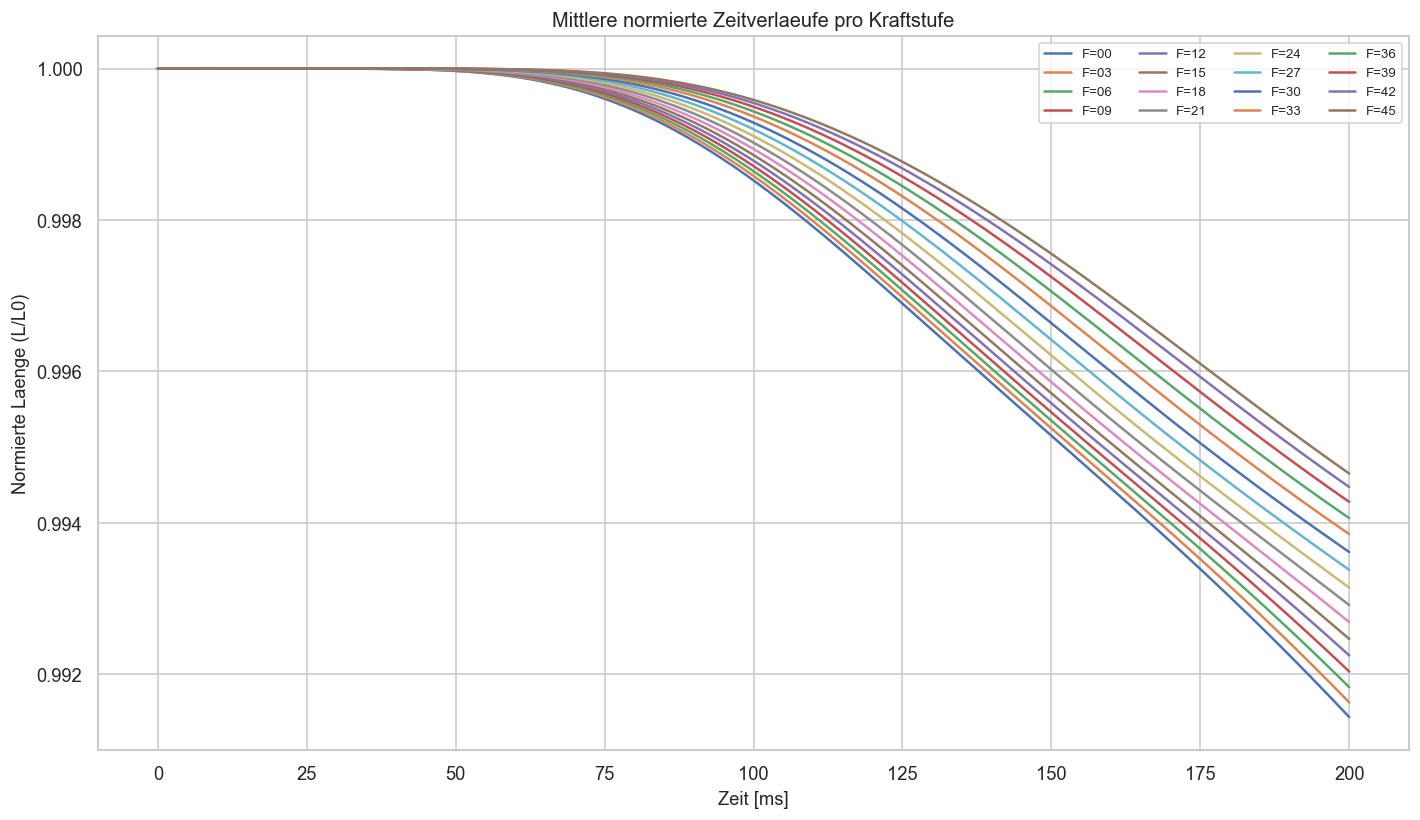

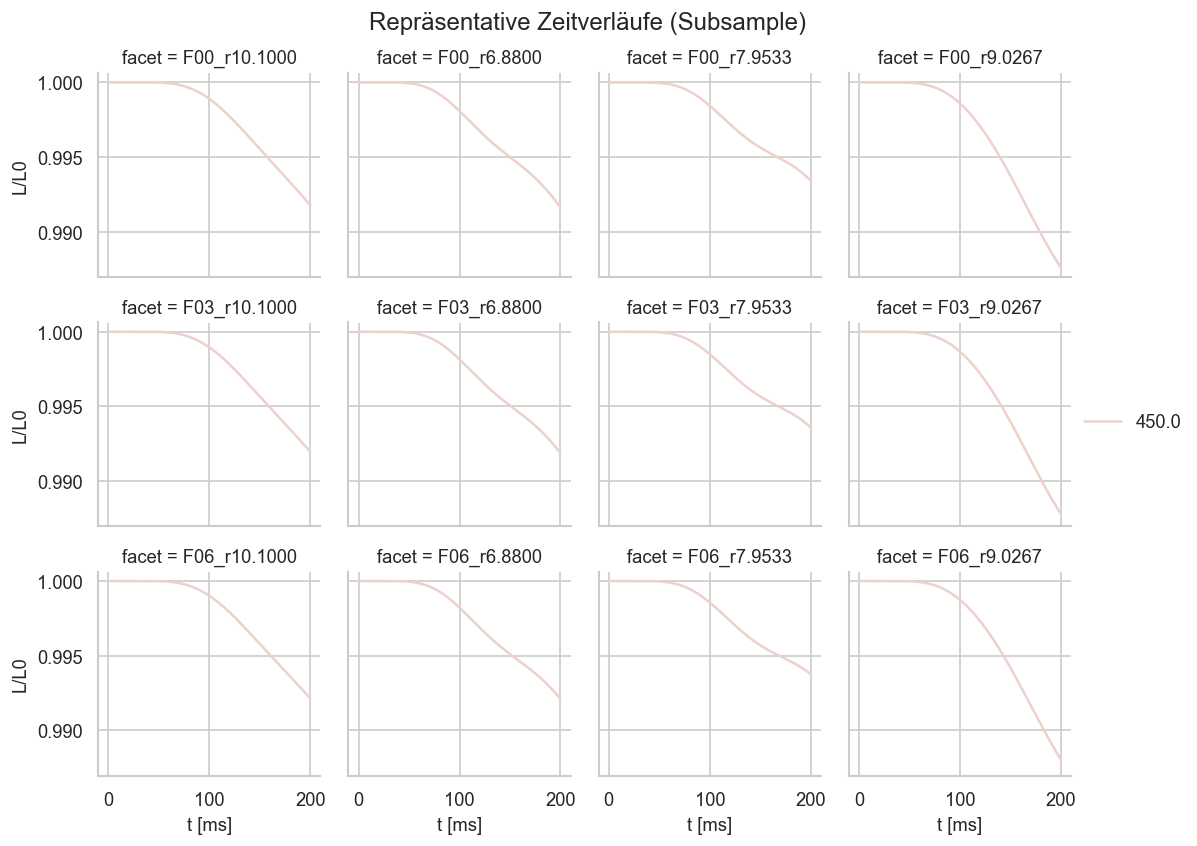

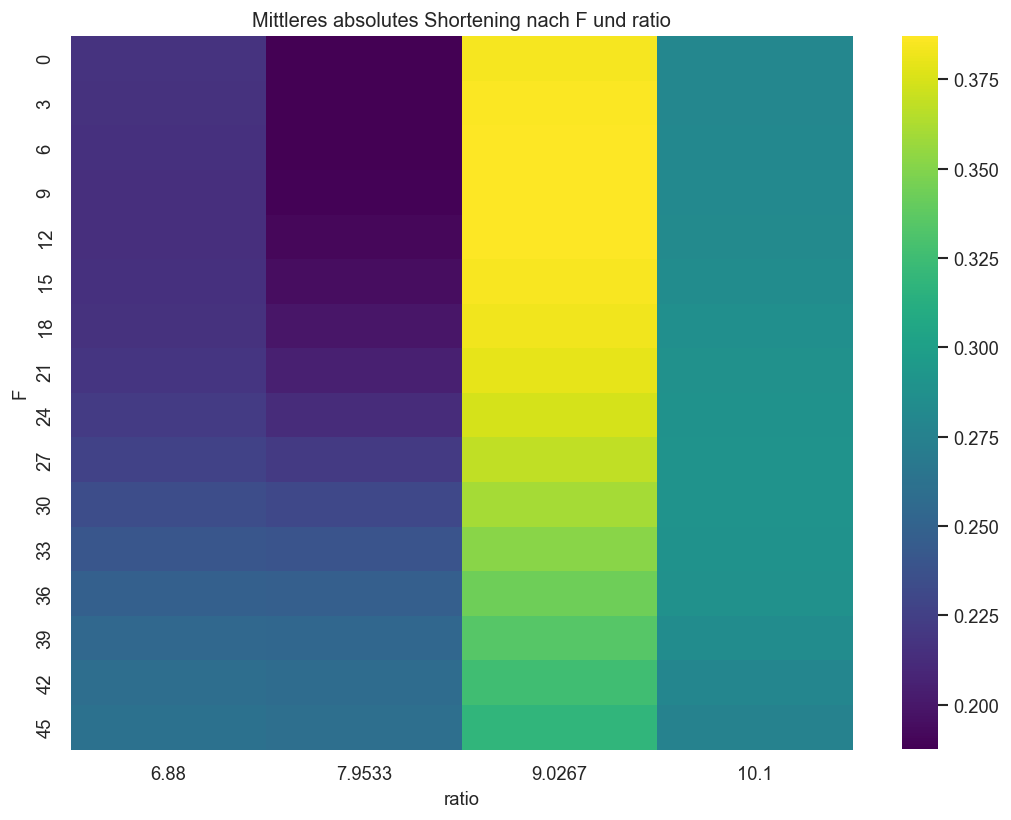

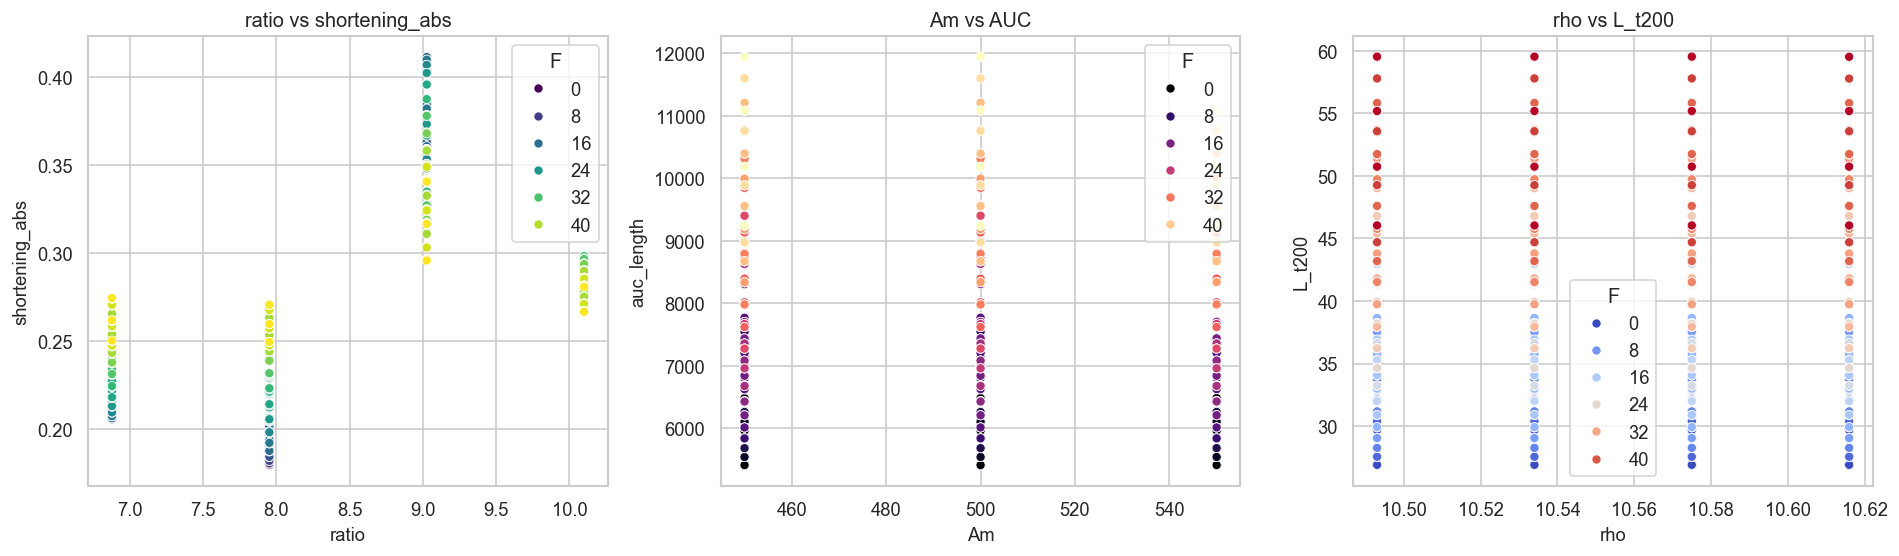

In [10]:
plot_df = trimmed_long_df.merge(
    summary_df[["setting_id", "F", "ratio", "Am", "rho", "shortening_abs", "shortening_rel", "dL_prestretch"]],
    on="setting_id",
    how="left"
)

# 8.1 Mittlerer Zeitverlauf je Kraftstufe (ueber alle anderen Parameter gemittelt)
mean_curve_F = (
    plot_df.groupby(["F", "t_ms"], as_index=False)["norm_to_t0"]
    .mean()
)

plt.figure(figsize=(12, 7))
for f_val in sorted(mean_curve_F["F"].unique()):
    g = mean_curve_F[mean_curve_F["F"] == f_val]
    plt.plot(g["t_ms"], g["norm_to_t0"], label=f"F={f_val:02d}")
plt.title("Mittlere normierte Zeitverlaeufe pro Kraftstufe")
plt.xlabel("Zeit [ms]")
plt.ylabel("Normierte Laenge (L/L0)")
plt.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

# 8.2 Facet-Plot: Zeitverlaeufe fuer repraesentative Kombinationen
# Nur eine reduzierte Stichprobe zur Lesbarkeit
sample_keys = (
    summary_df
    .sort_values(["F", "ratio", "Am", "rho"])
    .groupby(["F", "ratio"], as_index=False)
    .head(1)[["setting_id", "F", "ratio", "Am", "rho"]]
)
facet_df = plot_df.merge(sample_keys[["setting_id"]], on="setting_id", how="inner")
facet_df["facet"] = (
    "F" + facet_df["F"].astype(int).astype(str).str.zfill(2)
    + "_r" + facet_df["ratio"].map(lambda x: f"{x:.4f}")
)

# maximal 12 Facets
keep_facets = sorted(facet_df["facet"].unique())[:12]
facet_df = facet_df[facet_df["facet"].isin(keep_facets)].copy()

g = sns.FacetGrid(facet_df, col="facet", col_wrap=4, sharey=True, height=2.3)
g.map_dataframe(sns.lineplot, x="t_ms", y="norm_to_t0", hue="Am", estimator="mean", errorbar=None)
g.add_legend()
g.set_axis_labels("t [ms]", "L/L0")
g.fig.suptitle("Repräsentative Zeitverläufe (Subsample)", y=1.02)
plt.show()

# 8.3 Heatmap: mittleres Shortening nach F x ratio
heat_df = (
    summary_df.groupby(["F", "ratio"], as_index=False)["shortening_abs"]
    .mean()
)
heat_pivot = heat_df.pivot(index="F", columns="ratio", values="shortening_abs")

plt.figure(figsize=(9, 7))
sns.heatmap(heat_pivot, cmap="viridis", annot=False)
plt.title("Mittleres absolutes Shortening nach F und ratio")
plt.xlabel("ratio")
plt.ylabel("F")
plt.tight_layout()
plt.show()

# 8.4 Scatter-Plots fuer Haupteffekte
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

sns.scatterplot(data=summary_df, x="ratio", y="shortening_abs", hue="F", palette="viridis", ax=axes[0], s=30)
axes[0].set_title("ratio vs shortening_abs")

sns.scatterplot(data=summary_df, x="Am", y="auc_length", hue="F", palette="magma", ax=axes[1], s=30)
axes[1].set_title("Am vs AUC")

sns.scatterplot(data=summary_df, x="rho", y="L_t200", hue="F", palette="coolwarm", ax=axes[2], s=30)
axes[2].set_title("rho vs L_t200")

plt.tight_layout()
plt.show()

## 9. Parameter-vs-Kennzahlen auswerten (Korrelationen/Regression)

Konstante Parameter (aus Korrelations-/Regressionsanalyse ausgeschlossen): ['Vol']
Pearson-Korrelationen (Parameter -> Targets):
       dL_prestretch  dL_rel_prestretch  shortening_abs  shortening_rel    L_t200  auc_length  slope_init_0_10ms
F           0.978202           0.989035        0.084117       -0.558279  0.875337    0.873819                NaN
ratio       0.106152          -0.012520        0.588956        0.245519  0.447822    0.450993                NaN
Am         -0.022099          -0.000931       -0.180597       -0.114357 -0.080878   -0.081855                NaN
rho        -0.013764          -0.010945        0.000701        0.009860 -0.016565   -0.016516                NaN

Spearman-Korrelationen (Parameter -> Targets):
       dL_prestretch  dL_rel_prestretch  shortening_abs  shortening_rel    L_t200  auc_length  slope_init_0_10ms
F           0.992877           0.998292        0.200969       -0.622167  0.884686    0.881863                NaN
ratio       0.092059          -0

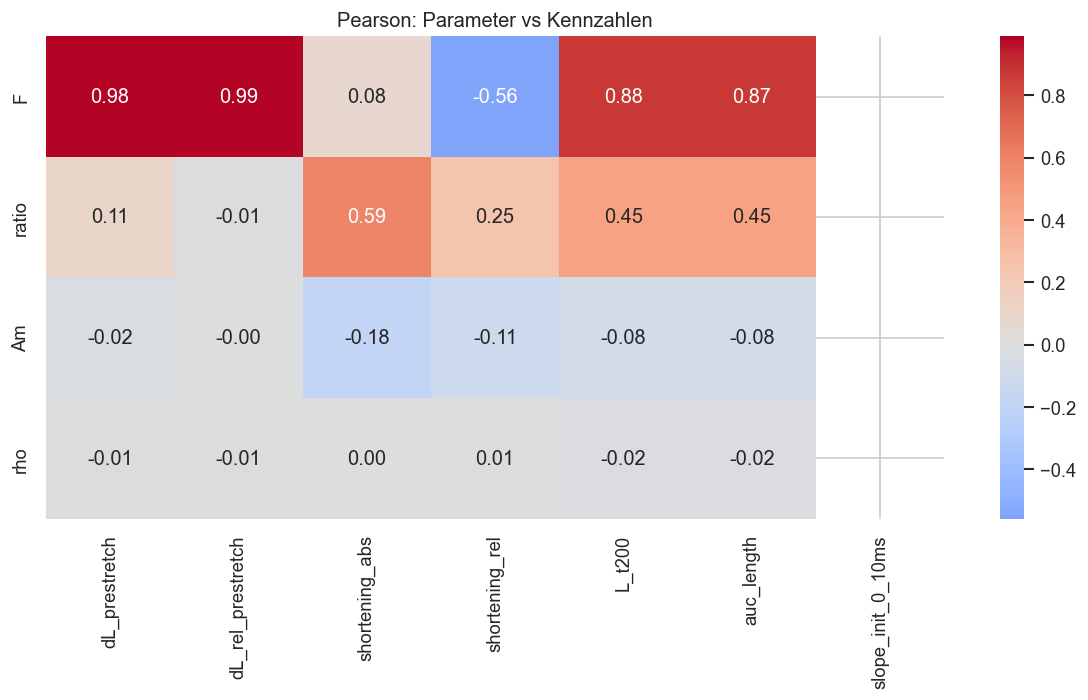


Lineares Modell fuer shortening_abs:
                            OLS Regression Results                            
Dep. Variable:         shortening_abs   R-squared:                       0.361
Model:                            OLS   Adj. R-squared:                  0.357
Method:                 Least Squares   F-statistic:                     98.20
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           3.10e-66
Time:                        21:02:39   Log-Likelihood:                 1065.3
No. Observations:                 700   AIC:                            -2121.
Df Residuals:                     695   BIC:                            -2098.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     

In [11]:
analysis_cols_all = ["F", "ratio", "Vol", "Am", "rho"]
target_cols = ["dL_prestretch", "dL_rel_prestretch", "shortening_abs", "shortening_rel", "L_t200", "auc_length", "slope_init_0_10ms"]

corr_input = summary_df[analysis_cols_all + target_cols].dropna().copy()

# Konstante Parameter fuer Statistik/Regression ausschliessen
analysis_cols = [c for c in analysis_cols_all if corr_input[c].nunique() > 1]
constant_cols = [c for c in analysis_cols_all if corr_input[c].nunique() <= 1]

if constant_cols:
    print("Konstante Parameter (aus Korrelations-/Regressionsanalyse ausgeschlossen):", constant_cols)

pearson_corr = corr_input[analysis_cols + target_cols].corr(method="pearson")
spearman_corr = corr_input[analysis_cols + target_cols].corr(method="spearman")

print("Pearson-Korrelationen (Parameter -> Targets):")
print(pearson_corr.loc[analysis_cols, target_cols])
print("\nSpearman-Korrelationen (Parameter -> Targets):")
print(spearman_corr.loc[analysis_cols, target_cols])

plt.figure(figsize=(10, 6))
sns.heatmap(pearson_corr.loc[analysis_cols, target_cols], annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Pearson: Parameter vs Kennzahlen")
plt.tight_layout()
plt.show()

# Optionale Regressionsmodelle
if HAS_STATSMODELS and len(analysis_cols) > 0:
    rhs = " + ".join(analysis_cols)
    formula = f"shortening_abs ~ {rhs}"

    print("\nLineares Modell fuer shortening_abs:")
    model = smf.ols(formula, data=corr_input).fit()
    print(model.summary())

    print("\nRobustes Modell (Huber) fuer shortening_abs:")
    X = corr_input[analysis_cols]
    X = sm.add_constant(X)
    y = corr_input["shortening_abs"]
    rlm_model = sm.RLM(y, X, M=sm.robust.norms.HuberT()).fit()
    print(rlm_model.summary())
else:
    print("Statsmodels nicht verfuegbar oder keine variablen Parameter, Regressionsblock uebersprungen.")

## 10. Ergebnisse als CSV und Abbildungen exportieren

In [12]:
output_dir = Path("/Users/canis/Library/CloudStorage/OneDrive-Persönlich/work/SdV/natwissKolleg/results/final_results/results_for_paper/da_4/new/analysis_outputs_all_settings")
output_dir.mkdir(parents=True, exist_ok=True)

# Tabellenexport
meta_plus.to_csv(output_dir / "meta_plus.csv", index=False)
prestretch_df.to_csv(output_dir / "prestretch_comparison.csv", index=False)
trim_info_df.to_csv(output_dir / "trim_info.csv", index=False)
trimmed_long_df.to_csv(output_dir / "timecourse_0_200ms_long.csv", index=False)
metrics_df.to_csv(output_dir / "metrics_per_setting.csv", index=False)
summary_df.to_csv(output_dir / "summary_all_settings.csv", index=False)
pearson_corr.to_csv(output_dir / "pearson_corr_full.csv")
spearman_corr.to_csv(output_dir / "spearman_corr_full.csv")

# Kompakte Tabelle fuer Paper-Weiterverwendung
compact_cols = [
    "setting_name", "F", "ratio", "Vol", "Am", "rho",
    "L_orig", "L_prestretch", "dL_prestretch", "dL_rel_prestretch",
    "L_t0", "L_min", "t_min_ms", "L_t200", "shortening_abs", "shortening_rel",
    "auc_length", "slope_init_0_10ms", "relaxation_abs"
]
summary_compact = summary_df[compact_cols].copy()
summary_compact.to_csv(output_dir / "summary_compact_for_paper.csv", index=False)

print("Export abgeschlossen nach:")
print(output_dir)
print("\nErzeugte Dateien:")
for p in sorted(output_dir.glob("*.csv")):
    print(" -", p.name)

Export abgeschlossen nach:
/Users/canis/Library/CloudStorage/OneDrive-Persönlich/work/SdV/natwissKolleg/results/final_results/results_for_paper/da_4/new/analysis_outputs_all_settings

Erzeugte Dateien:
 - meta_plus.csv
 - metrics_per_setting.csv
 - pearson_corr_full.csv
 - prestretch_comparison.csv
 - spearman_corr_full.csv
 - summary_all_settings.csv
 - summary_compact_for_paper.csv
 - timecourse_0_200ms_long.csv
 - trim_info.csv


### Zusatz: Hauptabbildungen als PNG exportieren

In [13]:
# Figure 1: Mittelkurven pro F
fig, ax = plt.subplots(figsize=(12, 7))
for f_val in sorted(mean_curve_F["F"].unique()):
    g = mean_curve_F[mean_curve_F["F"] == f_val]
    ax.plot(g["t_ms"], g["norm_to_t0"], label=f"F={f_val:02d}")
ax.set_title("Mittlere normierte Zeitverlaeufe pro Kraftstufe")
ax.set_xlabel("Zeit [ms]")
ax.set_ylabel("Normierte Laenge (L/L0)")
ax.legend(ncol=4, fontsize=8)
fig.tight_layout()
fig.savefig(output_dir / "fig_mean_timecourse_by_F.png", bbox_inches="tight")
plt.close(fig)

# Figure 2: Heatmap shortening_abs nach F x ratio
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(heat_pivot, cmap="viridis", annot=False, ax=ax)
ax.set_title("Mittleres absolutes Shortening nach F und ratio")
ax.set_xlabel("ratio")
ax.set_ylabel("F")
fig.tight_layout()
fig.savefig(output_dir / "fig_heatmap_shortening_F_ratio.png", bbox_inches="tight")
plt.close(fig)

# Figure 3: Parameter-Scatter
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
sns.scatterplot(data=summary_df, x="ratio", y="shortening_abs", hue="F", palette="viridis", ax=axes[0], s=30)
axes[0].set_title("ratio vs shortening_abs")
sns.scatterplot(data=summary_df, x="Am", y="auc_length", hue="F", palette="magma", ax=axes[1], s=30)
axes[1].set_title("Am vs AUC")
sns.scatterplot(data=summary_df, x="rho", y="L_t200", hue="F", palette="coolwarm", ax=axes[2], s=30)
axes[2].set_title("rho vs L_t200")
fig.tight_layout()
fig.savefig(output_dir / "fig_scatter_parameter_targets.png", bbox_inches="tight")
plt.close(fig)

# Figure 4: Pearson Heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pearson_corr.loc[analysis_cols, target_cols], annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Pearson: Parameter vs Kennzahlen")
fig.tight_layout()
fig.savefig(output_dir / "fig_pearson_parameter_targets.png", bbox_inches="tight")
plt.close(fig)

print("Abbildungen exportiert:")
for p in sorted(output_dir.glob("fig_*.png")):
    print(" -", p.name)

Abbildungen exportiert:
 - fig_heatmap_shortening_F_ratio.png
 - fig_mean_timecourse_by_F.png
 - fig_pearson_parameter_targets.png
 - fig_scatter_parameter_targets.png
